<a href="https://colab.research.google.com/github/oninonins/Machine-learning-/blob/main/Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Praktikum Filter

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image as im
import math

In [5]:
img = cv.imread('/content/drive/MyDrive/PCVK/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


In [6]:
def convolution2d(image, kernel, stride=1, padding=0):

    # Menambahkan padding jika nilai padding > 0
    if padding > 0:
        image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)
    else:
        image_padded = image.copy()

    k_height, k_width = kernel.shape
    img_height, img_width = image_padded.shape

    # Menghitung dimensi output
    out_height = int((img_height - k_height) / stride) + 1
    out_width = int((img_width - k_width) / stride) + 1

    output = np.zeros((out_height, out_width))

    # Proses konvolusi
    for y in range(0, out_height):
        for x in range(0, out_width):
            y_start = y * stride
            x_start = x * stride
            region = image_padded[y_start:y_start + k_height, x_start:x_start + k_width]
            output[y, x] = np.sum(region * kernel)

    # Clipping agar nilai piksel berada di rentang 0-255
    output = np.clip(output, 0, 255)
    return output.astype(np.uint8)

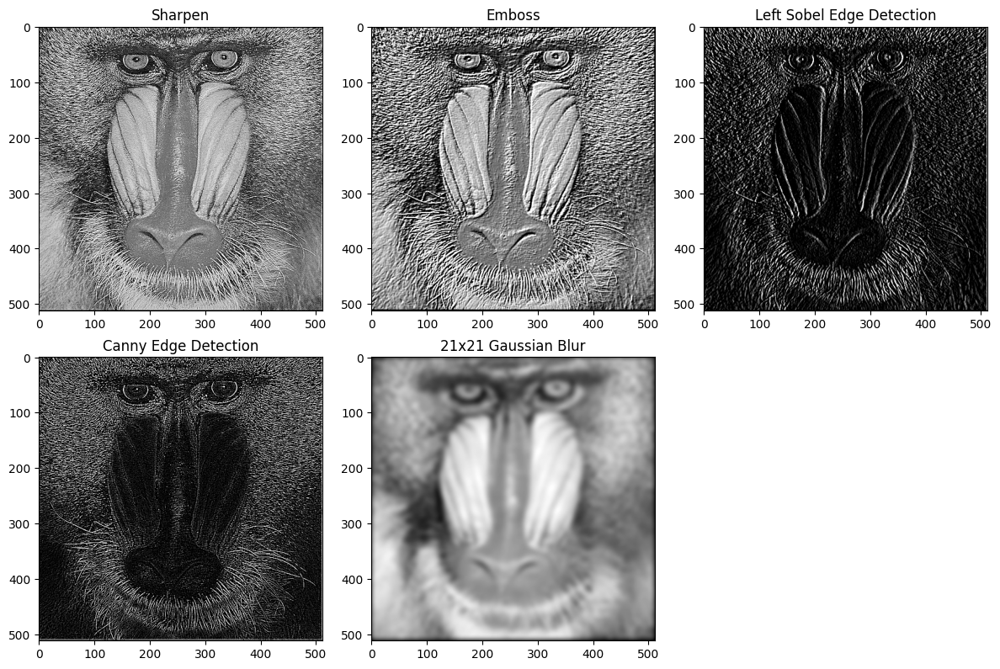

In [7]:


# Definisi Filter Tambahan (C.3.3)
kernel_avg = np.ones((3, 3), np.float32) / 9
kernel_lpf = np.array([[1, 1, 1], [1, 4, 1], [1, 1, 1]], dtype=np.float32) / 12
kernel_hpf = np.array([[-1, 0, 1], [-1, 0, 3], [-3, 0, 1]], dtype=np.float32)

# Definisi Filter pada Tabel Bagian D.3
kernel_sharpen = np.array([[0, -1, 0],
                          [-1, 5, -1],
                          [0, -1, 0]], dtype=np.float32)

kernel_emboss = np.array([[-2, -1, 0],
                         [-1, 1, 1],
                         [0, 1, 2]], dtype=np.float32)

kernel_left_sobel = np.array([[1, 0, -1],
                             [2, 0, -2],
                             [1, 0, -1]], dtype=np.float32)

kernel_canny_edge = np.array([[-1, -1, -1],
                             [-1, 8, -1],
                             [-1, -1, -1]], dtype=np.float32)

# Generate 21x21 Gaussian Blur Kernel
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_1d = cv.getGaussianKernel(kernel_size, sigma)
kernel_gaussian_21 = gaussian_1d @ gaussian_1d.transpose()

#  Konvolusi
res_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)
res_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=1)
res_left_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=1)
res_canny = convolution2d(img_gray, kernel_canny_edge, stride=1, padding=1)
res_gaussian_21 = convolution2d(img_gray, kernel_gaussian_21, stride=1, padding=10)

# Menampilkan Hasil
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1); plt.imshow(res_sharpen, cmap='gray'); plt.title('Sharpen')
plt.subplot(2, 3, 2); plt.imshow(res_emboss, cmap='gray'); plt.title('Emboss')
plt.subplot(2, 3, 3); plt.imshow(res_left_sobel, cmap='gray'); plt.title('Left Sobel Edge Detection')
plt.subplot(2, 3, 4); plt.imshow(res_canny, cmap='gray'); plt.title('Canny Edge Detection')
plt.subplot(2, 3, 5); plt.imshow(res_gaussian_21, cmap='gray'); plt.title('21x21 Gaussian Blur')
plt.tight_layout()
plt.show()

Percobaan 1

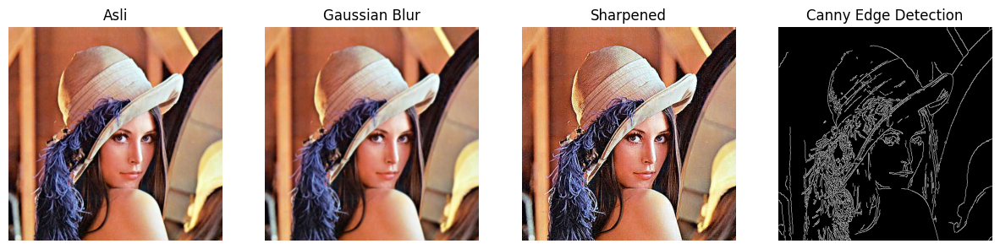

In [8]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:  # grayscale
            plt.imshow(img, cmap="gray")
        else:  # color
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img, (7, 7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)

sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, sharpened, edges],
                   ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

Percobaan 2

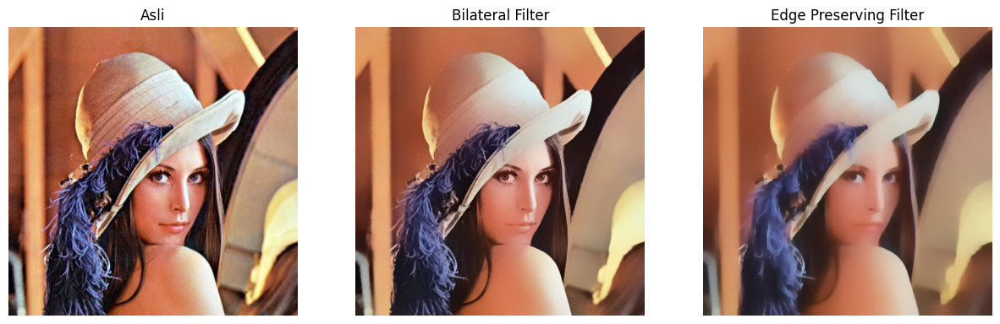

In [9]:
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserve],
                   ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

Percobaan 3

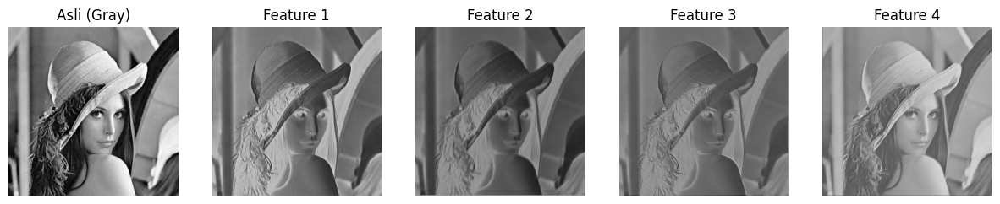

In [10]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])

Percobaan 4

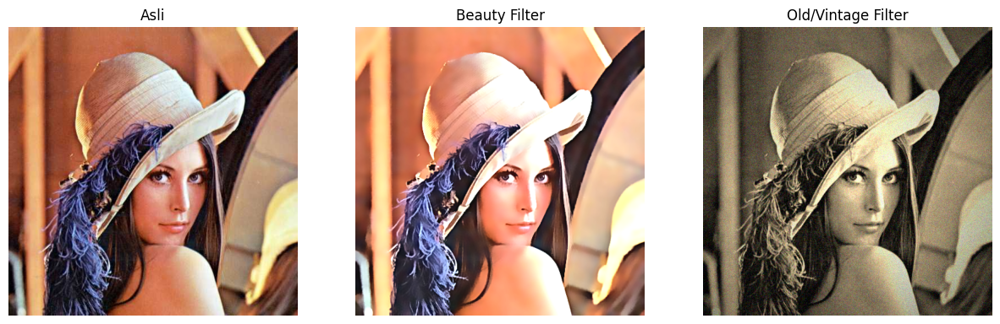

In [11]:
# 1. Beauty Filter
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0, 0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# 2. Old/Vintage Filter
# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols * 0.6)
kernel_y = cv.getGaussianKernel(rows, rows * 0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()

vignette = np.copy(sepia)
for i in range(3):
    vignette[:, :, i] = vignette[:, :, i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img, beauty, old_img], ["Asli", "Beauty Filter", "Old/Vintage Filter"])

Percobaan 5

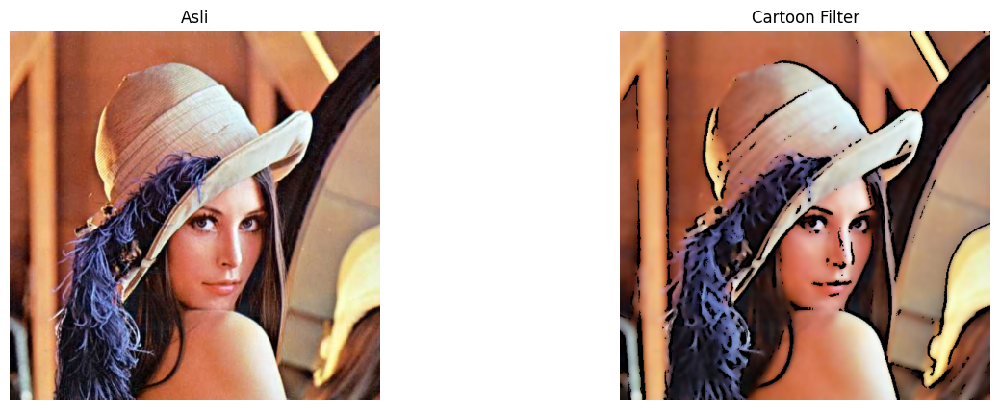

In [12]:
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

Percobaan 6

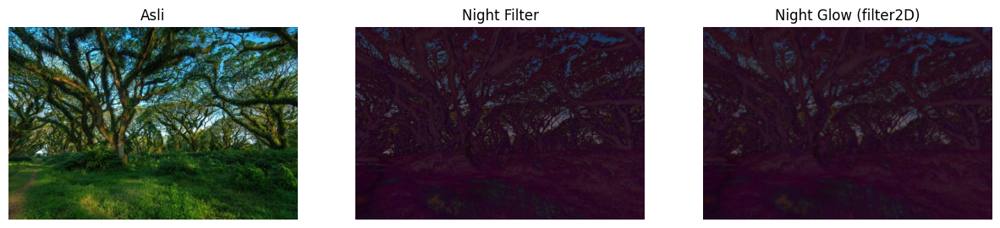

In [13]:
img_djawatan = cv.imread("/content/drive/MyDrive/PCVK/djawatan.jpg")
img_gray = cv.cvtColor(img_djawatan, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img_djawatan, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img_djawatan, night, night_glow],
                   ["Asli", "Night Filter", "Night Glow (filter2D)"])

Percobaan 7

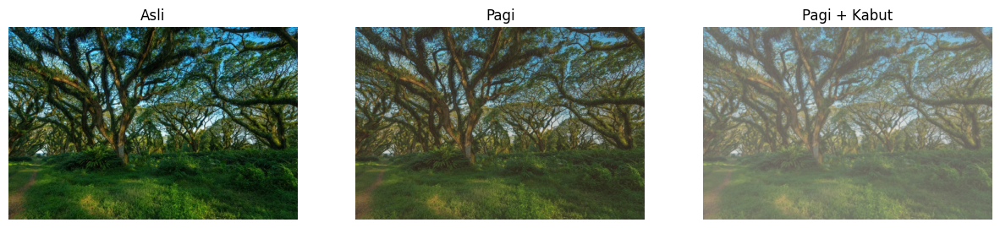

In [14]:
# Step 1: Kurangi kontras & cerahkan
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img_djawatan, alpha=alpha, beta=beta)

# Step 2: Tambahkan warm tone (kemerahan / oranye)
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T  # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# Tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img_djawatan, pagi, kabut],
                   ["Asli", "Pagi", "Pagi + Kabut"])

Tugas Praktikum

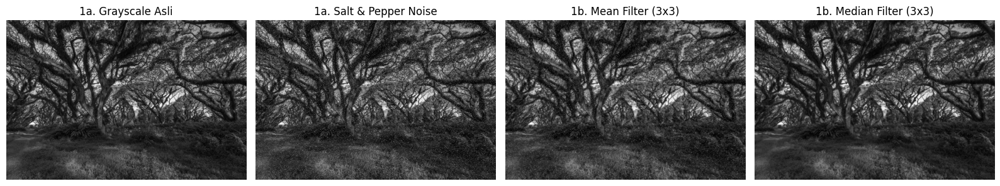

In [15]:
# a. Tambahkan noise Salt and Pepper
def add_salt_and_pepper_noise(image, amount=0.04):
    noisy = np.copy(image)
    # Salt noise (putih)
    num_salt = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
    noisy[tuple(coords)] = 255

    # Pepper noise (hitam)
    num_pepper = np.ceil(amount * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
    noisy[tuple(coords)] = 0
    return noisy

noisy_gray = add_salt_and_pepper_noise(img_gray, amount=0.05)

# b. Terapkan Mean Filter (3x3) dan Median Filter (3x3)
mean_filtered = cv.blur(noisy_gray, (3, 3))
median_filtered = cv.medianBlur(noisy_gray, 3)

# Visualisasi Hasil
plt.figure(figsize=(16, 5))
plt.subplot(1, 4, 1); plt.imshow(img_gray, cmap='gray'); plt.title('1a. Grayscale Asli'); plt.axis('off')
plt.subplot(1, 4, 2); plt.imshow(noisy_gray, cmap='gray'); plt.title('1a. Salt & Pepper Noise'); plt.axis('off')
plt.subplot(1, 4, 3); plt.imshow(mean_filtered, cmap='gray'); plt.title('1b. Mean Filter (3x3)'); plt.axis('off')
plt.subplot(1, 4, 4); plt.imshow(median_filtered, cmap='gray'); plt.title('1b. Median Filter (3x3)'); plt.axis('off')
plt.tight_layout()
plt.show()

cara kerj median filter : Menerapkan pengurutan nilai piksel di area tetangga 3x3 dan mengambil nilai tengah (median). Karena piksel noise bernilai sangat tinggi (255) atau sangat rendah (0) nilai median yang terpilih hampir selalu merupakan piksel asli di sekitarnya. Noise terhapus total tanpa mengaburkan tepi citra secara signifikan

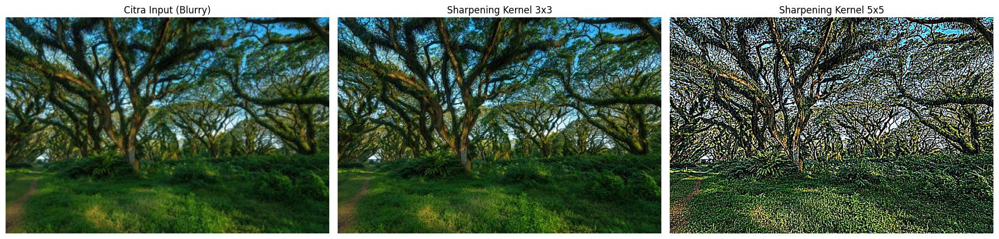

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Load citra dan buat versi sedikit buram (blurry)
img_path = '/content/drive/MyDrive/PCVK/djawatan.jpg'
img_bgr = cv.imread(img_path)

if img_bgr is None:
    raise FileNotFoundError("Gambar tidak ditemukan pada path yang diberikan.")

img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

# Membuat citra sedikit buram menggunakan Gaussian Blur
blurry_img = cv.GaussianBlur(img_rgb, (5, 5), 0)

# a. Mendefinisikan Kernel Penajaman (Sharpening) 3x3 dan 5x5
# Kernel 3x3 standar (jumlah elemen = 1 agar intensitas warna tetap stabil)
kernel_sharpen_3x3 = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)

# Kernel 5x5 penajaman tingkat lanjut (jumlah elemen = 1)
kernel_sharpen_5x5 = np.array([
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, 25, -1, -1],
    [-1, -1, -1, -1, -1],
    [-1, -1, -1, -1, -1]
], dtype=np.float32)

# b. Menerapkan konvolusi filter2D pada citra buram
sharpened_3x3 = cv.filter2D(blurry_img, -1, kernel_sharpen_3x3)
sharpened_5x5 = cv.filter2D(blurry_img, -1, kernel_sharpen_5x5)

# Visualisasi Perbandingan
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(blurry_img)
plt.title('Citra Input (Blurry)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpened_3x3)
plt.title('Sharpening Kernel 3x3')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(sharpened_5x5)
plt.title('Sharpening Kernel 5x5')
plt.axis('off')

plt.tight_layout()
plt.show()

Kernel 3x3:

Kejelasan Tepi: Meningkatkan ketajaman tepi dan kontras lokal secara pas

Kadar Noise/Distorsi: Sangat rendah, tidak membuat efek yang mengganggu pada area tekstur latar belakang

Kernel 5x5:

Kejelasan Tepi: Menajamkan tepi secara sangat agresif, jadi over

Kadar Noise/Distorsi: Sangat tinggi Kernel ini mengamplifikasi noise frekuensi tinggi secara berlebihan sehingga membuat citra tampak kasar dan penuh kontras yang merusak tekstur alamiah gambar

In [16]:
# Fungsi kartun(image)
def kartun(image):
    #Penghalusan warna menggunakan Bilateral Filter agar area warna rata
    color = cv.bilateralFilter(image, d=9, sigmaColor=200, sigmaSpace=200)

    # Deteksi garis tepi menggunakan Adaptive Thresholding
    gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
    gray_blur = cv.medianBlur(gray, 7)
    edges = cv.adaptiveThreshold(
        gray_blur, 255,
        cv.ADAPTIVE_THRESH_MEAN_C,
        cv.THRESH_BINARY, 9, 9
    )

    # Penggabungan menggunakan operasi bitwise AND
    # Konversi edges ke 3 channel BGR agar bisa digabung
    edges_colored = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
    cartoon_img = cv.bitwise_and(color, edges_colored)

    return cartoon_img


NameError: name 'img_bgr' is not defined

Saving abel.jpeg to abel.jpeg


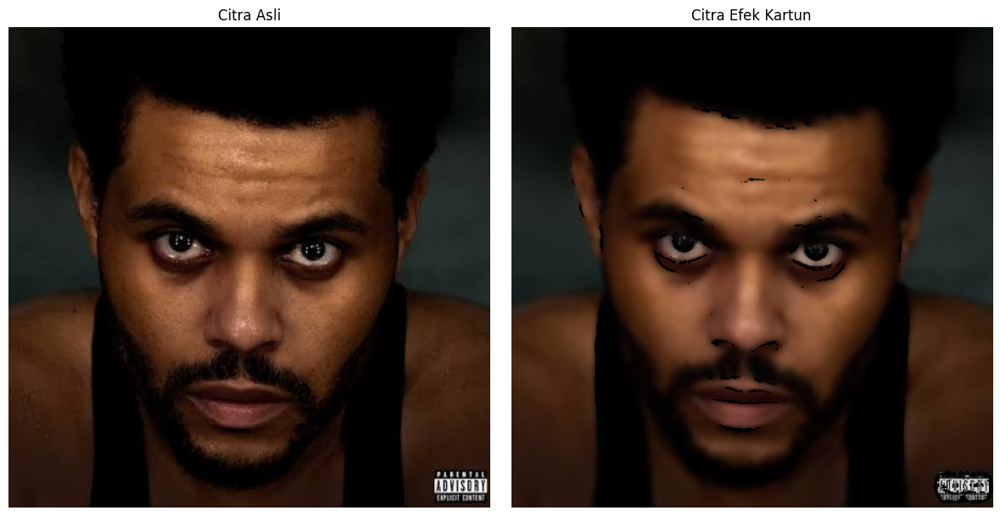

In [20]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
img_bytes = uploaded[file_name]
img_bgr = cv.imdecode(np.frombuffer(img_bytes, np.uint8), cv.IMREAD_COLOR)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

cartoon_result_bgr = kartun(img_bgr)
cartoon_result_rgb = cv.cvtColor(cartoon_result_bgr, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1); plt.imshow(img_rgb); plt.title('Citra Asli'); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(cartoon_result_rgb); plt.title('Citra Efek Kartun'); plt.axis('off')
plt.tight_layout()
plt.show()